# 10 — Baseline Algorithm Benchmark (Option C)

**Mục đích:** So sánh **≥5 thuật toán** trên cùng protocol (777-d, seed 42, test, τ=0.50).

**Tier 1 (fair internal) — 6 mô hình:**
1. Logistic Regression *(train mới)*
2. Linear SVM calibrated *(train mới)*
3. Random Forest *(train mới)*
4. XGBoost raw 777-d *(artifact Phase 5)*
5. CNN-BiLSTM sequence *(artifact Phase 5)*
6. **Weighted blend** *(artifact Phase 5 — đề xuất)*

**Tier 2:** `literature_sota_comparison.csv` — bảng tham chiếu, **không** gộp cùng trục biểu đồ Tier 1.

**Chạy:** Colab CPU hoặc local (~15–25 phút). Cần Phase 2 features + Phase 7 metrics.

**Đầu ra:**
- `reports/tables/baseline_benchmark_metrics.csv`
- `reports/tables/baseline_benchmark_model_config.csv`
- `artifacts/evaluation/baseline_benchmark_metadata.json`
- `reports/figures/benchmark_tier1_macro_f1.png`

In [ ]:
# import importlib: import thư viện importlib
import importlib
# import json: đọc/ghi JSON metadata
import json
# import os: biến môi trường hệ thống
import os
# import subprocess: chạy lệnh pip/cài package
import subprocess
# import sys: tham số Python runtime
import sys
# from datetime import datetime, timezone: import thư viện datetime
from datetime import datetime, timezone
# from pathlib import Path: quản lý đường dẫn
from pathlib import Path

# import matplotlib.pyplot: vẽ biểu đồ
import matplotlib.pyplot as plt
# import numpy: tính toán mảng số
import numpy as np
# import pandas: xử lý DataFrame
import pandas as pd
# from sklearn.calibration import CalibratedClassifierCV: thư viện machine learning scikit-learn
from sklearn.calibration import CalibratedClassifierCV
# from sklearn.ensemble import RandomForestClassifier: thư viện machine learning scikit-learn
from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression: thư viện machine learning scikit-learn
from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (: thư viện machine learning scikit-learn
from sklearn.metrics import (
    # accuracy_score,: thực thi lệnh Python
    accuracy_score,
    # average_precision_score,: thực thi lệnh Python
    average_precision_score,
    # brier_score_loss,: thực thi lệnh Python
    brier_score_loss,
    # confusion_matrix,: thực thi lệnh Python
    confusion_matrix,
    # f1_score,: thực thi lệnh Python
    f1_score,
    # precision_score,: thực thi lệnh Python
    precision_score,
    # recall_score,: thực thi lệnh Python
    recall_score,
    # roc_auc_score,: thực thi lệnh Python
    roc_auc_score,
# ): đóng ngoặc gọi hàm
)
# from sklearn.pipeline import Pipeline: thư viện machine learning scikit-learn
from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler: thư viện machine learning scikit-learn
from sklearn.preprocessing import StandardScaler
# from sklearn.svm import LinearSVC: thư viện machine learning scikit-learn
from sklearn.svm import LinearSVC

# %matplotlib inline: thực thi lệnh Python
%matplotlib inline
# plt.rcParams["figure.dpi"] = 110: thực thi lệnh Python
plt.rcParams["figure.dpi"] = 110
# plt.rcParams["savefig.dpi"] = 160: thực thi lệnh Python
plt.rcParams["savefig.dpi"] = 160

# SEED: biến cấu hình/hằng số của notebook
SEED = 42
# THRESHOLD: biến cấu hình/hằng số của notebook
THRESHOLD = 0.5
# THRESHOLD_STRATEGY: biến cấu hình/hằng số của notebook
THRESHOLD_STRATEGY = "default_0.5"
# SPLIT: biến cấu hình/hằng số của notebook
SPLIT = "test"
# print("[OK] Libraries ready:", sys.version.split()[0]): in thông tin ra console
print("[OK] Libraries ready:", sys.version.split()[0])


[OK] Libraries ready: 3.10.8


In [ ]:
# tim_thu_muc_goc: hàm xử lý tim thu muc goc
def tim_thu_muc_goc() -> Path:
    # candidates: list[Path] = []: chuyển/chiếu thành list
    candidates: list[Path] = []
    # env_root = ...: ép kiểu chuỗi
    env_root = os.environ.get("FAKE_REVIEWS_PROJECT_ROOT", "").strip()
    # if: điều kiện — if env_root:
    if env_root:
        # candidates.append(Path(env_root)): thực thi lệnh Python
        candidates.append(Path(env_root))
    # cwd = ...: gán giá trị cho biến cwd
    cwd = Path.cwd().resolve()
    # candidates.extend([cwd, cwd.parent]): thực thi lệnh Python
    candidates.extend([cwd, cwd.parent])
    # candidates.extend([: thực thi lệnh Python
    candidates.extend([
        # Path("/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"),: thực thi lệnh Python
        Path("/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"),
        # Path("/content/drive/MyDrive/Fake_reviews"),: thực thi lệnh Python
        Path("/content/drive/MyDrive/Fake_reviews"),
    # ]): đóng list comprehension hoặc danh sách
    ])
    # for: vòng lặp — for path in candidates:
    for path in candidates:
        # if: điều kiện — if path.exists() and (path / "artifacts" / "features" / "fea
        if path.exists() and (path / "artifacts" / "features" / "features_raw_train.npy").exists():
            # return: trả kết quả từ hàm
            return path
    # raise FileNotFoundError("Không tìm thấy Fake_reviews. Mount Drive hoặc đặt FAKE_...: ném lỗi và dừng cell
    raise FileNotFoundError("Không tìm thấy Fake_reviews. Mount Drive hoặc đặt FAKE_REVIEWS_PROJECT_ROOT.")

# PROJECT_ROOT: biến cấu hình/hằng số của notebook
PROJECT_ROOT = tim_thu_muc_goc()
# FEAT_DIR: biến cấu hình/hằng số của notebook
FEAT_DIR = PROJECT_ROOT / "artifacts" / "features"
# PRED_DIR: biến cấu hình/hằng số của notebook
PRED_DIR = PROJECT_ROOT / "artifacts" / "predictions"
# TABLE_DIR: biến cấu hình/hằng số của notebook
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
# FIGURE_DIR: biến cấu hình/hằng số của notebook
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
# EVAL_DIR: biến cấu hình/hằng số của notebook
EVAL_DIR = PROJECT_ROOT / "artifacts" / "evaluation"
# for: vòng lặp — for d in [PRED_DIR, TABLE_DIR, FIGURE_DIR, EVAL_DIR]:
for d in [PRED_DIR, TABLE_DIR, FIGURE_DIR, EVAL_DIR]:
    # d.mkdir(parents=True, exist_ok=True): tạo thư mục nếu chưa có
    d.mkdir(parents=True, exist_ok=True)
# print("[OK] PROJECT_ROOT:", PROJECT_ROOT): in thông tin ra console
print("[OK] PROJECT_ROOT:", PROJECT_ROOT)


[OK] PROJECT_ROOT: C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews


In [ ]:
# SKLEARN_MODELS: biến cấu hình/hằng số của notebook
SKLEARN_MODELS = {
    # "sklearn_logistic_regression": {"display_name": "Logistic Regression", "group": ...: hiển thị bảng/kết quả trên notebook
    "sklearn_logistic_regression": {"display_name": "Logistic Regression", "group": "classical", "order": 1},
    # "sklearn_linear_svc": {"display_name": "Linear SVM (calibrated)", "group": "clas...: hiển thị bảng/kết quả trên notebook
    "sklearn_linear_svc": {"display_name": "Linear SVM (calibrated)", "group": "classical", "order": 2},
    # "sklearn_random_forest": {"display_name": "Random Forest", "group": "classical",...: hiển thị bảng/kết quả trên notebook
    "sklearn_random_forest": {"display_name": "Random Forest", "group": "classical", "order": 3},
# }: đóng khối từ điển
}
# ARTIFACT_MODELS: biến cấu hình/hằng số của notebook
ARTIFACT_MODELS = [
    # {"model_variant": "phase5_xgb_raw", "display_name": "XGBoost raw 777-d", "group"...: hiển thị bảng/kết quả trên notebook
    {"model_variant": "phase5_xgb_raw", "display_name": "XGBoost raw 777-d", "group": "pipeline", "order": 4, "highlight": 0},
    # {"model_variant": "phase5_cnn_bilstm_sequence", "display_name": "CNN-BiLSTM sequ...: hiển thị bảng/kết quả trên notebook
    {"model_variant": "phase5_cnn_bilstm_sequence", "display_name": "CNN-BiLSTM sequence", "group": "pipeline", "order": 5, "highlight": 0},
    # {"model_variant": "phase5_weighted_blend", "display_name": "Weighted blend (de x...: hiển thị bảng/kết quả trên notebook
    {"model_variant": "phase5_weighted_blend", "display_name": "Weighted blend (de xuat)", "group": "pipeline", "order": 6, "highlight": 1},
# ]: đóng khối danh sách
]

# build_estimator: hàm xử lý build estimator
def build_estimator(model_variant: str):
    # if: điều kiện — if model_variant == "sklearn_logistic_regression":
    if model_variant == "sklearn_logistic_regression":
        # return: trả kết quả từ hàm
        return Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED, n_jobs=-1))])
    # if: điều kiện — if model_variant == "sklearn_linear_svc":
    if model_variant == "sklearn_linear_svc":
        # return: trả kết quả từ hàm
        return Pipeline([("scaler", StandardScaler()), ("clf", CalibratedClassifierCV(LinearSVC(max_iter=3000, class_weight="balanced", dual="auto", random_state=SEED), cv=3, method="sigmoid"))])
    # if: điều kiện — if model_variant == "sklearn_random_forest":
    if model_variant == "sklearn_random_forest":
        # return: trả kết quả từ hàm
        return Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1))])
    # raise KeyError(model_variant): ném lỗi và dừng cell
    raise KeyError(model_variant)

# compute_metrics: hàm xử lý compute metrics
def compute_metrics(y_true, y_prob, threshold):
    # y_pred = ...: ép kiểu dữ liệu cột
    y_pred = (y_prob >= threshold).astype(int)
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel(): thực thi lệnh Python
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    # return: trả kết quả từ hàm
    return {
        # "accuracy": float(accuracy_score(y_true, y_pred)),: ép kiểu số thực
        "accuracy": float(accuracy_score(y_true, y_pred)),
        # "macro_f1": float(f1_score(y_true, y_pred, average="macro")),: ép kiểu số thực
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        # "precision_fake": float(precision_score(y_true, y_pred, pos_label=1, zero_divisi...: ép kiểu số thực
        "precision_fake": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        # "recall_fake": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0))...: ép kiểu số thực
        "recall_fake": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        # "f1_fake": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),: ép kiểu số thực
        "f1_fake": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        # "roc_auc": float(roc_auc_score(y_true, y_prob)),: ép kiểu số thực
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        # "pr_auc": float(average_precision_score(y_true, y_prob)),: ép kiểu số thực
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        # "brier_score": float(brier_score_loss(y_true, y_prob)),: ép kiểu số thực
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        # "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),: ép kiểu số nguyên
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        # "support_real": int((y_true == 0).sum()), "support_fake": int((y_true == 1).sum(...: ép kiểu số nguyên
        "support_real": int((y_true == 0).sum()), "support_fake": int((y_true == 1).sum()),
    # }: đóng khối từ điển
    }

# x_train = ...: nạp mảng từ file .npy
x_train = np.load(FEAT_DIR / "features_raw_train.npy")
# x_test = ...: nạp mảng từ file .npy
x_test = np.load(FEAT_DIR / "features_raw_test.npy")
# y_train = ...: nạp mảng từ file .npy
y_train = np.load(FEAT_DIR / "labels_train.npy")
# y_test = ...: nạp mảng từ file .npy
y_test = np.load(FEAT_DIR / "labels_test.npy")
# print(f"[OK] Features train={x_train.shape}, test={x_test.shape}"): in thông tin ra console
print(f"[OK] Features train={x_train.shape}, test={x_test.shape}")


[OK] Features train=(29923, 777), test=(6413, 777)


In [ ]:
# generated_at = ...: gán giá trị cho biến generated at
generated_at = datetime.now(timezone.utc).isoformat()
# rows = ...: gán giá trị cho biến rows
rows = []

# for: vòng lặp — for model_variant, spec in SKLEARN_MODELS.items():
for model_variant, spec in SKLEARN_MODELS.items():
    # print(f"[TRAIN] {model_variant} ..."): in thông tin ra console
    print(f"[TRAIN] {model_variant} ...")
    # est = ...: gán giá trị cho biến est
    est = build_estimator(model_variant)
    # est.fit(x_train, y_train): fit model/reducer trên dữ liệu train
    est.fit(x_train, y_train)
    # y_prob = ...: dự đoán nhãn/xác suất
    y_prob = est.predict_proba(x_test)[:, 1]
    # prob_path = ...: gán giá trị cho biến prob path
    prob_path = PRED_DIR / f"{model_variant}_{SPLIT}_prob.npy"
    # np.save(prob_path, y_prob): lưu mảng numpy ra file .npy
    np.save(prob_path, y_prob)
    # metrics = ...: gán giá trị cho biến metrics
    metrics = compute_metrics(y_test, y_prob, THRESHOLD)
    # rows.append({: thực thi lệnh Python
    rows.append({
        # "generated_at_utc": generated_at, "seed": SEED, "split": SPLIT, "tier": "tier1_f...: ép kiểu số nguyên
        "generated_at_utc": generated_at, "seed": SEED, "split": SPLIT, "tier": "tier1_fair_internal",
        # "model_variant": model_variant, "display_name": spec["display_name"], "model_gro...: hiển thị bảng/kết quả trên notebook
        "model_variant": model_variant, "display_name": spec["display_name"], "model_group": spec["group"],
        # "display_order": spec["order"], "highlight": 0, "evidence_type": "trained_sklear...: hiển thị bảng/kết quả trên notebook
        "display_order": spec["order"], "highlight": 0, "evidence_type": "trained_sklearn_baseline",
        # "threshold": THRESHOLD, "threshold_strategy": THRESHOLD_STRATEGY,: ép kiểu chuỗi
        "threshold": THRESHOLD, "threshold_strategy": THRESHOLD_STRATEGY,
        # "probability_path": str(prob_path), "notes": "Fair Tier-1 benchmark @ tau=0.5.",...: ép kiểu chuỗi
        "probability_path": str(prob_path), "notes": "Fair Tier-1 benchmark @ tau=0.5.", **metrics,
    # }): đóng từ điển hoặc DataFrame constructor
    })
    # print(f"  macro_f1={metrics['macro_f1']:.4f}"): in thông tin ra console
    print(f"  macro_f1={metrics['macro_f1']:.4f}")

# df_phase7 = ...: đọc file CSV vào DataFrame
df_phase7 = pd.read_csv(TABLE_DIR / "phase7_final_metrics.csv")
# mask = ...: ép kiểu chuỗi
mask = (df_phase7["seed"] == SEED) & (df_phase7["split"] == SPLIT) & (df_phase7["threshold"] == THRESHOLD) & (df_phase7["threshold_strategy"] == THRESHOLD_STRATEGY)
# for: vòng lặp — for spec in ARTIFACT_MODELS:
for spec in ARTIFACT_MODELS:
    # row = ...: gán giá trị cho biến row
    row = df_phase7.loc[df_phase7["model_variant"] == spec["model_variant"]].loc[mask].iloc[0]
    # rows.append({: thực thi lệnh Python
    rows.append({
        # "generated_at_utc": generated_at, "seed": SEED, "split": SPLIT, "tier": "tier1_f...: ép kiểu số nguyên
        "generated_at_utc": generated_at, "seed": SEED, "split": SPLIT, "tier": "tier1_fair_internal",
        # "model_variant": spec["model_variant"], "display_name": spec["display_name"], "m...: hiển thị bảng/kết quả trên notebook
        "model_variant": spec["model_variant"], "display_name": spec["display_name"], "model_group": spec["group"],
        # "display_order": spec["order"], "highlight": spec["highlight"], "evidence_type":...: hiển thị bảng/kết quả trên notebook
        "display_order": spec["order"], "highlight": spec["highlight"], "evidence_type": "phase7_artifact_reuse",
        # "threshold": THRESHOLD, "threshold_strategy": THRESHOLD_STRATEGY,: ép kiểu chuỗi
        "threshold": THRESHOLD, "threshold_strategy": THRESHOLD_STRATEGY,
        # "probability_path": row["probability_path"], "notes": "Reused phase7_final_metri...: thực thi lệnh Python
        "probability_path": row["probability_path"], "notes": "Reused phase7_final_metrics.csv; no retrain.",
        # "accuracy": float(row["accuracy"]), "macro_f1": float(row["macro_f1"]),: ép kiểu số thực
        "accuracy": float(row["accuracy"]), "macro_f1": float(row["macro_f1"]),
        # "precision_fake": float(row["precision_fake"]), "recall_fake": float(row["recall...: ép kiểu số thực
        "precision_fake": float(row["precision_fake"]), "recall_fake": float(row["recall_fake"]),
        # "f1_fake": float(row["f1_fake"]), "roc_auc": float(row["roc_auc"]),: ép kiểu số thực
        "f1_fake": float(row["f1_fake"]), "roc_auc": float(row["roc_auc"]),
        # "pr_auc": float(row["pr_auc"]), "brier_score": float(row["brier_score"]),: ép kiểu số thực
        "pr_auc": float(row["pr_auc"]), "brier_score": float(row["brier_score"]),
        # "tn": int(row["tn"]), "fp": int(row["fp"]), "fn": int(row["fn"]), "tp": int(row[...: ép kiểu số nguyên
        "tn": int(row["tn"]), "fp": int(row["fp"]), "fn": int(row["fn"]), "tp": int(row["tp"]),
        # "support_real": int(row["support_real"]), "support_fake": int(row["support_fake"...: ép kiểu số nguyên
        "support_real": int(row["support_real"]), "support_fake": int(row["support_fake"]),
    # }): đóng từ điển hoặc DataFrame constructor
    })

# df_benchmark = ...: hiển thị bảng/kết quả trên notebook
df_benchmark = pd.DataFrame(rows).sort_values("display_order").reset_index(drop=True)
# out_csv = ...: gán giá trị cho biến out csv
out_csv = TABLE_DIR / "baseline_benchmark_metrics.csv"
# df_benchmark.to_csv(out_csv, index=False): ghi DataFrame ra file CSV
df_benchmark.to_csv(out_csv, index=False)
# config = ...: hiển thị bảng/kết quả trên notebook
config = df_benchmark[["model_variant", "display_name", "model_group", "display_order", "highlight", "tier"]].rename(
    # columns = ...: hiển thị bảng/kết quả trên notebook
    columns={"display_name": "ten_hien_thi", "model_group": "nhom", "display_order": "thu_tu"}
# ): đóng ngoặc gọi hàm
)
# config.to_csv(TABLE_DIR / "baseline_benchmark_model_config.csv", index=False): ghi DataFrame ra file CSV
config.to_csv(TABLE_DIR / "baseline_benchmark_model_config.csv", index=False)
# metadata = ...: gán giá trị cho biến metadata
metadata = {
    # "generated_at_utc": generated_at, "seed": SEED, "tier1_model_count": len(df_benc...: đếm số phần tử
    "generated_at_utc": generated_at, "seed": SEED, "tier1_model_count": len(df_benchmark),
    # "sklearn_models": list(SKLEARN_MODELS.keys()),: chuyển/chiếu thành list
    "sklearn_models": list(SKLEARN_MODELS.keys()),
    # "artifact_models": [s["model_variant"] for s in ARTIFACT_MODELS],: thực thi lệnh Python
    "artifact_models": [s["model_variant"] for s in ARTIFACT_MODELS],
# }: đóng khối từ điển
}
# (EVAL_DIR / "baseline_benchmark_metadata.json").write_text(json.dumps(metadata, ...: ghi dictionary ra JSON
(EVAL_DIR / "baseline_benchmark_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
# print(f"[OK] {len(df_benchmark)} models -> {out_csv.name}"): in thông tin ra console
print(f"[OK] {len(df_benchmark)} models -> {out_csv.name}")
# display(df_benchmark[["display_name", "macro_f1", "precision_fake", "recall_fake...: hiển thị bảng/kết quả trên notebook
display(df_benchmark[["display_name", "macro_f1", "precision_fake", "recall_fake", "roc_auc"]])


[TRAIN] sklearn_logistic_regression ...
  macro_f1=0.8734
[TRAIN] sklearn_linear_svc ...
  macro_f1=0.8741
[TRAIN] sklearn_random_forest ...
  macro_f1=0.8906
[OK] 6 models -> baseline_benchmark_metrics.csv


,display_name,macro_f1,precision_fake,recall_fake,roc_auc
0,Logistic Regression,0.873356,0.870036,0.826601,0.936453
1,Linear SVM (calibrated),0.874118,0.906865,0.790396,0.935103
2,Random Forest,0.890642,0.959832,0.783155,0.924374
3,XGBoost raw 777-d,0.905938,0.968579,0.810595,0.953063
4,CNN-BiLSTM sequence,0.934290,0.946500,0.896723,0.972582
5,Weighted blend (de xuat),0.943320,0.969872,0.895579,0.976900


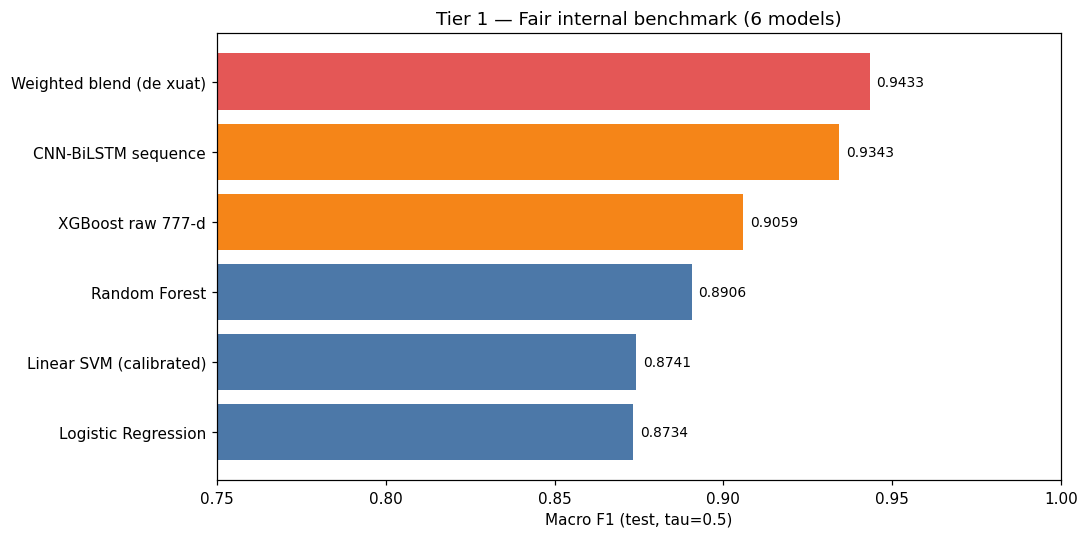

[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\benchmark_tier1_macro_f1.png


In [ ]:
# fig, ax = plt.subplots(figsize=(10, 5)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(10, 5))
# colors = ...: gán giá trị cho biến colors
colors = ["#4C78A8" if g == "classical" else "#F58518" for g in df_benchmark["model_group"]]
# colors[-1] = ": thực thi lệnh Python
colors[-1] = "#E45756"
# ax.barh(df_benchmark["display_name"], df_benchmark["macro_f1"], color=colors): hiển thị bảng/kết quả trên notebook
ax.barh(df_benchmark["display_name"], df_benchmark["macro_f1"], color=colors)
# ax.set_xlabel("Macro F1 (test, tau=0.5)"): tạo tập hợp
ax.set_xlabel("Macro F1 (test, tau=0.5)")
# ax.set_title("Tier 1 — Fair internal benchmark (6 models)"): tạo tập hợp
ax.set_title("Tier 1 — Fair internal benchmark (6 models)")
# ax.set_xlim(0.75, 1.0): tạo tập hợp
ax.set_xlim(0.75, 1.0)
# for: vòng lặp — for i, v in enumerate(df_benchmark["macro_f1"]):
for i, v in enumerate(df_benchmark["macro_f1"]):
    # ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9): thực thi lệnh Python
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# fig_path = ...: gán giá trị cho biến fig path
fig_path = FIGURE_DIR / "benchmark_tier1_macro_f1.png"
# fig.savefig(fig_path, dpi=160, bbox_inches="tight"): thực thi lệnh Python
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
# plt.show(): hiển thị biểu đồ
plt.show()
# print("[LƯU]", fig_path): in thông tin ra console
print("[LƯU]", fig_path)


In [ ]:
# lit_path = ...: gán giá trị cho biến lit path
lit_path = TABLE_DIR / "literature_sota_comparison.csv"
# if: điều kiện — if lit_path.exists():
if lit_path.exists():
    # df_lit = ...: đọc file CSV vào DataFrame
    df_lit = pd.read_csv(lit_path).head(8)
    # df_lit.to_csv(TABLE_DIR / "baseline_benchmark_literature_tier2.csv", index=False...: ghi DataFrame ra file CSV
    df_lit.to_csv(TABLE_DIR / "baseline_benchmark_literature_tier2.csv", index=False)
    # print("[OK] Tier 2 literature (không gộp biểu đồ Tier 1):"): in thông tin ra console
    print("[OK] Tier 2 literature (không gộp biểu đồ Tier 1):")
    # display(df_lit[["rank", "method", "metric_name", "score", "comparable_to_ours", ...: hiển thị bảng/kết quả trên notebook
    display(df_lit[["rank", "method", "metric_name", "score", "comparable_to_ours", "notes"]])
# else: nhánh còn lại của điều kiện
else:
    # print("[CẢNH BÁO] Thiếu literature_sota_comparison.csv"): in thông tin ra console
    print("[CẢNH BÁO] Thiếu literature_sota_comparison.csv")


[OK] Tier 2 literature (không gộp biểu đồ Tier 1):


,rank,method,metric_name,score,comparable_to_ours,notes
0,1,Ours weighted_blend balanced,Macro F1,0.9463,Yes,phase7_final_metrics.csv seed42; multiseed mea...
1,2,Ours weighted_blend default,Macro F1,0.9433,Yes,phase7_final_metrics.csv 2026-06-10
2,3,Ours CNN-BiLSTM sequence,Macro F1,0.9324,Yes,Single best DL track
3,4,Veluru et al. BERT+ResNet-50,F1,0.934,Partial,Multimodal text+image; not same dataset
4,5,XGB/LGBM raw 777,Macro F1,~0.906,Yes,Tree strong baseline in our pipeline
5,6,Refaeli & Hajek fine-tuned BERT,F1,Not standardized macro,Partial,Transformer only
6,7,Bhuvaneshwari CNN-BiLSTM-Attention,F1/Acc,>0.90 area,Partial,DL without modern transformer+behavioral stack
7,8,Duma hybrid text+ratings+aspects,F1,Paper best,Partial,Uses ratings/aspects not our 9 behavioral


In [ ]:
# best = ...: lấy giá trị lớn nhất
best = df_benchmark.loc[df_benchmark["macro_f1"].idxmax()]
# rf = ...: gán giá trị cho biến rf
rf = df_benchmark.loc[df_benchmark["model_variant"] == "sklearn_random_forest"].iloc[0]
# blend = ...: đếm số phần tử
blend = df_benchmark.loc[df_benchmark["model_variant"] == "phase5_weighted_blend"].iloc[0]
# delta = ...: đếm số phần tử
delta = blend["macro_f1"] - rf["macro_f1"]
# print(f"[INSIGHT 1] Tier 1 có {len(df_benchmark)} mô hình (>=5 yêu cầu)."): in thông tin ra console
print(f"[INSIGHT 1] Tier 1 có {len(df_benchmark)} mô hình (>=5 yêu cầu).")
# print(f"[INSIGHT 2] Weighted blend Macro F1 = {blend['macro_f1']:.4f} vượt Rando...: in thông tin ra console
print(f"[INSIGHT 2] Weighted blend Macro F1 = {blend['macro_f1']:.4f} vượt Random Forest +{delta:.4f} trên cùng protocol.")
# print(f"[INSIGHT 3] Classical best = {rf['display_name']} ({rf['macro_f1']:.4f})...: hiển thị bảng/kết quả trên notebook
print(f"[INSIGHT 3] Classical best = {rf['display_name']} ({rf['macro_f1']:.4f}); pipeline đề xuất = {best['display_name']} ({best['macro_f1']:.4f}).")
# print("[INSIGHT 4] Literature Tier 2 chỉ tham chiếu — dataset/metric có thể khác...: in thông tin ra console
print("[INSIGHT 4] Literature Tier 2 chỉ tham chiếu — dataset/metric có thể khác (xem comparable_to_ours).")

[INSIGHT 1] Tier 1 có 6 mô hình (>=5 yêu cầu).
[INSIGHT 2] Weighted blend Macro F1 = 0.9433 vượt Random Forest +0.0527 trên cùng protocol.
[INSIGHT 3] Classical best = Random Forest (0.8906); pipeline đề xuất = Weighted blend (de xuat) (0.9433).
[INSIGHT 4] Literature Tier 2 chỉ tham chiếu — dataset/metric có thể khác (xem comparable_to_ours).
